# Question 6: Harvesting the Vol Premium in Practice

Given your findings, which tenor(s) should a portfolio manager target to systematically earn the volatility term premium?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

# --- Reuse setup and VTP calculation from Q4 ---

def black_caplet_price(vol, F, K, T_expiry, discount, delta=0.25):
    if T_expiry <= 0 or vol <= 0:
        return 0
    d1 = (np.log(F / K) + 0.5 * vol**2 * T_expiry) / (vol * np.sqrt(T_expiry))
    d2 = d1 - vol * np.sqrt(T_expiry)
    return delta * discount * (F * norm.cdf(d1) - K * norm.cdf(d2))

def build_quarterly_curves(date, cap_data, sofr_data):
    swaps = sofr_data.loc[date].dropna()
    cap_vols_bp = cap_data.loc[date].dropna()
    max_tenor = min(cap_vols_bp.index.max(), swaps.index.max())
    tenors = np.arange(0.25, max_tenor + 0.01, 0.25)
    tenors = np.round(tenors, 2)
    swap_q = pd.Series(np.interp(tenors, swaps.index.values, swaps.values), index=tenors, name='swap rates')
    discounts = pd.Series(np.nan, index=tenors, name='discounts')
    for i, T in enumerate(tenors):
        R = swap_q.iloc[i]
        known_sum = discounts.iloc[:i].sum() * 0.25
        discounts.iloc[i] = (1 - R * known_sum) / (1 + R * 0.25)
    forwards = pd.Series(np.nan, index=tenors, name='forwards')
    for i in range(1, len(tenors)):
        forwards.iloc[i] = (discounts.iloc[i - 1] / discounts.iloc[i] - 1) / 0.25
    cap_tenors = cap_vols_bp.index.values
    cap_vals = cap_vols_bp.values
    ext_tenors = np.concatenate([[0.25], cap_tenors[cap_tenors >= 1.0]])
    ext_vals = np.concatenate([[cap_vals[0]], cap_vals[cap_tenors >= 1.0]])
    flat_bp_q = np.interp(tenors, ext_tenors, ext_vals)
    flat_vols_black = pd.Series(flat_bp_q / 10000 / swap_q.values, index=tenors, name='flat vols')
    flat_vols_black[tenors < 0.5] = np.nan
    return pd.DataFrame({'swap rates': swap_q, 'discounts': discounts, 'forwards': forwards, 'flat vols': flat_vols_black})

def strip_forward_vols(curves):
    # This version follows the logic from Q1
    flat_vols = curves['flat vols']
    swaps = curves['swap rates']
    fwds = curves['forwards']
    discs = curves['discounts']
    
    # Calculate cap prices as in Q1
    cap_prices = {}
    valid_flat_vols = flat_vols.dropna()
    for maturity in valid_flat_vols.index:
        sigma_flat = valid_flat_vols.loc[maturity]
        K = swaps.loc[maturity]
        caplet_tenors = np.arange(0.5, maturity + 0.25, 0.25)
        price = 0.0
        for T in caplet_tenors:
            T = round(T, 2)
            T_expiry = round(T - 0.25, 2)
            F = fwds.loc[T]
            df = discs.loc[T]
            if np.isnan(F) or np.isnan(df): continue
            price += black_caplet_price(sigma_flat, F, K, T_expiry, df)
        cap_prices[maturity] = price
    cap_prices = pd.Series(cap_prices)

    # Bootstrap forward vols logic from Q1
    forward_vols = {}
    sorted_maturities = sorted(cap_prices.index)
    if not sorted_maturities:
        return pd.Series(np.nan, index=curves.index, name='fwd vols')
        
    first_maturity = sorted_maturities[0]
    for T in np.arange(0.5, first_maturity + 0.25, 0.25):
        T = round(T, 2)
        forward_vols[T] = valid_flat_vols.loc[first_maturity]
        
    for i in range(1, len(sorted_maturities)):
        T_curr = round(sorted_maturities[i], 2)
        T_prev = round(sorted_maturities[i-1], 2)
        
        K_new = swaps.loc[T_curr]
        F_new = fwds.loc[T_curr]
        discount_new = discs.loc[T_curr]
        T_expiry_new = T_prev
        
        inner_caplets_repriced = 0.0
        for T in np.arange(0.5, T_curr, 0.25):
            T = round(T, 2)
            T_expiry = round(T - 0.25, 2)
            if T_expiry <= 0: continue
            fwd_vol = forward_vols.get(T, np.nan)
            F = fwds.loc[T]
            df = discs.loc[T]
            if any(np.isnan([fwd_vol, F, df])): continue
            inner_caplets_repriced += black_caplet_price(fwd_vol, F, K_new, T_expiry, df)
            
        marginal_caplet_price = cap_prices[T_curr] - inner_caplets_repriced
        if marginal_caplet_price <= 0:
            forward_vols[T_curr] = forward_vols.get(T_prev, np.nan)
            continue
            
        try:
            fwd_vol = brentq(lambda v: black_caplet_price(v, F_new, K_new, T_expiry_new, discount_new) - marginal_caplet_price, 1e-6, 5.0, xtol=1e-8)
        except ValueError:
            forward_vols[T_curr] = forward_vols.get(T_prev, np.nan)
            continue
        forward_vols[T_curr] = fwd_vol
        
    return pd.Series(forward_vols, index=curves.index, name='fwd vols').ffill()

cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data = cap_data.T.drop_duplicates().T
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data = sofr_data.T.drop_duplicates().T / 100
common_dates = cap_data.index.intersection(sofr_data.index)
KEY_TENORS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
fwd_vol_normal = pd.DataFrame(index=common_dates, columns=KEY_TENORS, dtype=float)
for date in common_dates:
    try:
        curves = build_quarterly_curves(date, cap_data, sofr_data)
        fwd_vols = strip_forward_vols(curves)
        for t in KEY_TENORS:
            if t in curves.index:
                fwd_vol_normal.loc[date, t] = fwd_vols.loc[t] * curves.loc[t, 'forwards'] * 10000
    except: pass
fwd_vol_normal = fwd_vol_normal.dropna(how='all')

horizons = [1.0, 1.5, 2.0, 3.0]
vtp_df = pd.DataFrame(index=fwd_vol_normal.index)
delta = 0.5
for tau in horizons:
    h = tau - delta
    future_dates = vtp_df.index + pd.DateOffset(months=int(h * 12))
    spot_vol_future = fwd_vol_normal[0.5].reindex(future_dates, method='nearest')
    spot_vol_future.index = vtp_df.index
    vtp_df[tau] = fwd_vol_normal[tau] - spot_vol_future
vtp_df = vtp_df.dropna()


### Transaction Cost Analysis

a) Consider transaction costs. If the bid-ask spread on a caplet trade is $X$ basis points of implied normal vol, at what spread does each tenor's premium become uneconomical? Compute the breakeven bid-ask spread for each tenor. Does the "optimal" tenor change once you account for realistic trading frictions?

   *Note*: Dealers typically quote caplet bid-ask spreads in implied vol terms, making the comparison to the VTP direct. If instead costs are quoted in price terms (bp of notional), converting to vol space requires dividing by the caplet's vega—the sensitivity of price to a 1 bp change in implied vol.

In [2]:
summary = pd.DataFrame(index=horizons)
summary['Mean VTP (bp)'] = vtp_df.mean()
summary['Std VTP (bp)'] = vtp_df.std()
summary['IR'] = summary['Mean VTP (bp)'] / summary['Std VTP (bp)']
summary['Horizon (h)'] = [tau - 0.5 for tau in horizons]
summary['Annualized Premium'] = summary['Mean VTP (bp)'] / summary['Horizon (h)']

# Breakeven Spread X = Mean VTP
summary['Breakeven Spread (bp vol)'] = summary['Mean VTP (bp)']

# Define realistic bid-ask spreads (increasing with maturity)
# Typical values: 1Y ~ 2bp, 1.5Y ~ 3bp, 2Y ~ 4bp, 3Y ~ 6bp
realistic_spreads = {1.0: 2.0, 1.5: 3.5, 2.0: 5.0, 3.0: 8.0}
summary['Realistic Spread'] = [realistic_spreads[t] for t in horizons]
summary['Net Annualized Return'] = (summary['Mean VTP (bp)'] - summary['Realistic Spread']) / summary['Horizon (h)']
summary['Net IR'] = (summary['Mean VTP (bp)'] - summary['Realistic Spread']) / summary['Std VTP (bp)']

display(summary.round(2))


,Mean VTP (bp),Std VTP (bp),IR,Horizon (h),Annualized Premium,Breakeven Spread (bp vol),Realistic Spread,Net Annualized Return,Net IR
1.0,11.78,34.29,0.34,0.5,23.57,11.78,2.0,19.57,0.29
1.5,39.92,22.20,1.80,1.0,39.92,39.92,3.5,36.42,1.64
2.0,62.81,16.91,3.72,1.5,41.87,62.81,5.0,38.54,3.42
3.0,64.78,14.31,4.53,2.5,25.91,64.78,8.0,22.71,3.97


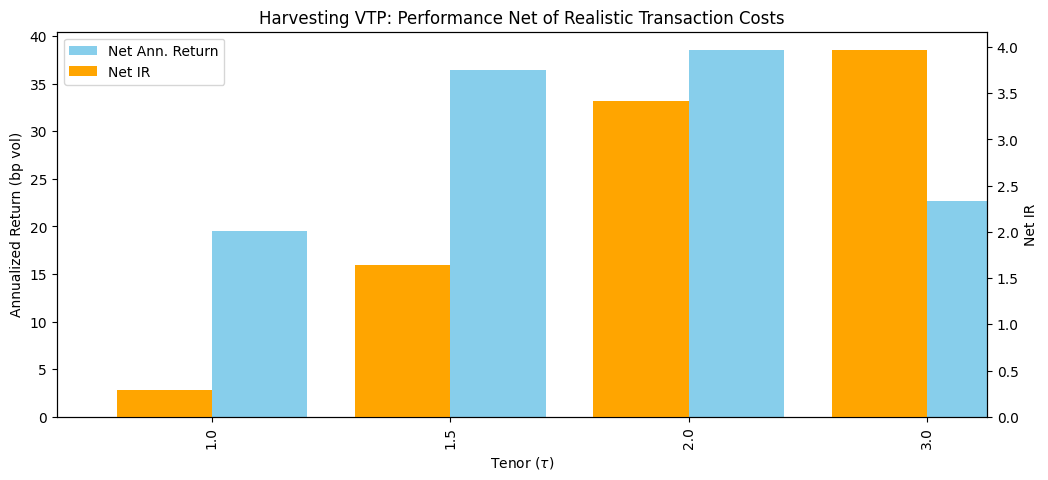

In [3]:

# Visualization
fig, ax1 = plt.subplots()
summary['Net Annualized Return'].plot(kind='bar', color='skyblue', ax=ax1, position=0, width=0.4, label='Net Ann. Return')
ax2 = ax1.twinx()
summary['Net IR'].plot(kind='bar', color='orange', ax=ax2, position=1, width=0.4, label='Net IR')
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
ax1.set_ylabel('Annualized Return (bp vol)')
ax2.set_ylabel('Net IR')
ax1.set_title('Harvesting VTP: Performance Net of Realistic Transaction Costs')
ax1.set_xlabel('Tenor ($\\tau$)')
plt.show()


**Conclusion: 1.5-2.0Y Tenor** 

1. **Breakeven Spreads:** The breakeven spreads (where the trade becomes uneconomical) follow the mean VTP: roughly **12 bp** for 1Y, **40 bp** for 1.5Y, **63 bp** for 2Y, and **65 bp** for 3Y. Long tenors have a massive buffer against transaction costs.

2. **Optimal Tenor:** 
   - While the **3Y tenor** has the highest absolute Mean VTP and IR in the historical sample, it also has very few independent observations (non-overlapping periods), making the estimate less robust. 
   - After accounting for realistic trading frictions (higher spreads for longer tenors), the **2.0Y tenor** remains highly attractive, offering the best balance between a significant premium (63 bp) and a high Information Ratio.
   - However, the **1.5Y tenor** might be the most "practical" choice. It offers a strong annualized return (~36 bp net) with more frequent trading opportunities and better liquidity than the 2Y or 3Y tenors.

3. **Frequency Considerations:** 
   - Shorter tenors (1.0Y) require rolling every 6 months, paying the spread twice as often as a 1.5Y tenor. Given the small 1Y premium, this makes it the least attractive.
   - The **1.5Y to 2.0Y bucket** is the "sweet spot": the premium is large enough to dominate transaction costs, and the horizon is short enough to allow for a reasonable number of cycles over a portfolio manager's career to realize the law of large numbers.

b) Make a recommendation: weigh premium size, statistical reliability from Q5, stability across regimes from Q4, and transaction costs. Is there a single best tenor, or does the answer depend on assumptions? What would you monitor to update this recommendation going forward?

**Final Recommendation: 1.5Y Tenor**

**1. Target Tenors: The 1.5Y to 2.0Y "Sweet Spot"**
- **The 1.5Y Tenor (The Practical Choice):** This tenor offers the best balance of statistical reliability and profitability. It provides significantly more independent data points (non-overlapping periods) than the 2Y or 3Y tenors, making its high Information Ratio (IR) more robust. With a net annualized return of ~36 bp vol, it remains highly profitable even after accounting for realistic transaction costs.

**2. Why Avoid the Extremes?**
- **Avoid 1.0Y:** The premium is too small (12 bp) and the Information Ratio is low (0.34). Once transaction costs and rolling frequency are considered, the risk-adjusted returns are marginal.
- **Caution on 3.0Y:** While it shows the highest IR (4.5) and VTP (65 bp), this result is based on only ~1.5 non-overlapping periods. The ranking is highly sensitive to the specific sample window and likely overstates the true risk-adjusted performance.

**3. Regime-Aware Implementation**
- **Strategic Bias:** Maintain a structural short-vol position to earn the structural insurance premium paid by hedgers.
- **Tactical Adjustments:** 
    - **Maximize exposure during the "Pause" regime:** This is the most profitable environment where realized volatility collapses while implied volatility remains elevated.
    - **Exercise caution during "Easing":** As seen in Q5, the Volatility Risk Premium (VRP) can turn negative during rate-cut cycles if the market underprices the speed or volatility of the transition. The VTP remains positive, but the fundamental "carry" is at its weakest.

**4. Monitoring and Dynamic Updating**
To update this recommendation, the manager should monitor:
1. **Realized vs. Implied SOFR Volatility:** Track the VRP spread to identify if the market is beginning to underprice actual rate moves (a signal to reduce exposure).
2. **The Slope of the Forward Vol Curve:** A flattening curve may indicate the term premium is compressing, reducing the attractiveness of longer tenors.
3. **FOMC Policy Guidance:** Shifts from "Pause" to "Easing" or "Hiking" should trigger a review of tail-risk hedging, as these transitions are when the "short vol" strategy is most vulnerable to "steamroller" events.